## Merge k-mer and mapping-based coverage calculations

All files on farm in `/home/ctbrown/scratch3/2025-workflow-core99/`

In [1]:
# base checkout of workflow directory is here:
BASE='/home/ctbrown/scratch3/2025-workflow-core99/'

# outputs from running `do_mapping`:
BASE_OUTPUTS=BASE+'/outputs.mapping/bams.cds.rand'

# where to place figures
FIG_OUT=BASE+'/outputs.figures/'

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import scipy
import math
import sourmash
import collections

import seaborn as sns
from matplotlib.legend_handler import HandlerTuple

## Do genes correlate with each other when they are from the same species?

tl;dr many do

In [49]:
rand_gene_df = pl.read_parquet('../inputs.abundhist/mapping-coverage.parquet')
highcov_gene_df = pl.read_parquet('../inputs.abundhist/mapping-coverage-highcov-metag.parquet')

gene_df = pl.concat([rand_gene_df, highcov_gene_df])

gene_df

metag,species,gene,len,hits,breadth,depth_all,depth_cov,anchor,description
str,str,str,i64,i64,f64,f64,f64,i64,str
"""SRR17241485""","""s__Phascolarctobacterium_A suc…","""CNENGHLA_00658""",1179,383,0.324852,3.201866,9.856397,0,"""BLAST match to 4-hydroxy-3-met…"
"""SRR17241485""","""s__Phascolarctobacterium_A suc…","""CNENGHLA_01260""",1398,545,0.389843,3.907725,10.023853,1,"""BLAST match to hydrogenase lar…"
"""ERR3211974""","""s__UBA2868 sp004552595""","""IPIMNMMB_00240""",1995,151,0.075689,0.075689,1.0,0,"""type I DNA topoisomerase [Lach…"
"""ERR3211974""","""s__UBA2868 sp004552595""","""IEHIAHIF_00466""",1431,76,0.05311,0.05311,1.0,0,"""L-arabinose isomerase [Lachnos…"
"""ERR3211974""","""s__UBA2868 sp004552595""","""KMEHCMKH_00746""",1083,314,0.289935,0.43675,1.506369,1,"""multiple monosaccharide ABC tr…"
…,…,…,…,…,…,…,…,…,…
"""SRR17241640""","""s__Prevotella sp000434975""","""APOLKBKG_00160""",3177,2137,0.672647,4.85395,7.216191,1,"""efflux RND transporter permeas…"
"""SRR17241640""","""s__Prevotella sp000434975""","""IGEONAAO_00273""",423,260,0.614657,6.219858,10.119231,0,"""hypothetical protein"""
"""SRR18048908""","""s__Prevotella sp000434975""","""APOLKBKG_00160""",3177,3177,1.0,16.341832,16.341832,1,"""efflux RND transporter permeas…"


found defined anchor gene OMBJBIHD_01711 for s__Lactobacillus amylovorus


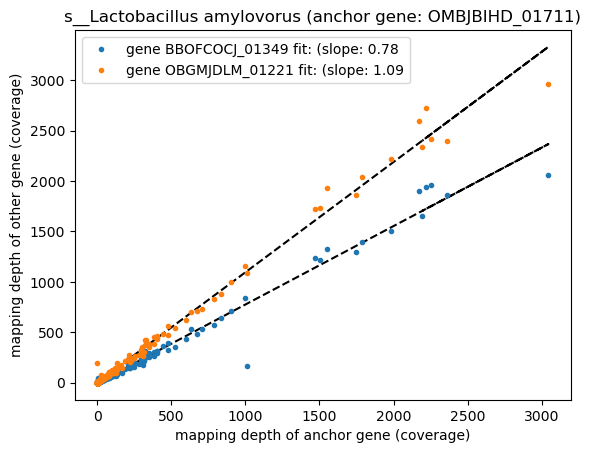

In [52]:
def plot_genes_correlation(df, species, *, xmax=None, ymax=None):
    xx_df = df.filter(pl.col("species") == species).drop_nans()

    genes = list(sorted(xx_df['gene'].unique().to_list()))

    # is an anchor gene set?
    if len(xx_df.filter(pl.col("anchor") == 1)):
        agene_list = xx_df.filter(pl.col("anchor") == 1)['gene'].unique().to_list()
        assert len(agene_list) == 1, agene_list
        anchor_gene = agene_list[0]
        genes.remove(anchor_gene)
        print(f"found defined anchor gene {anchor_gene} for {species}")
    else:
        anchor_gene = genes.pop()

    anchor_df = xx_df.filter(pl.col('gene') == anchor_gene).with_columns(
        pl.col('depth_all').alias("anchor_depth")
    )

    for gene in genes:
        this_df = xx_df.filter(pl.col('gene') == gene).with_columns(
            pl.col('depth_all').alias("this_depth")
        )
        yy_df = this_df.join(anchor_df, on='metag', how='inner')
        x = yy_df['anchor_depth'].to_list()
        y = yy_df['this_depth'].to_list()
        coef = np.polyfit(x, y, 1)
        poly1d_fn = np.poly1d(coef) 
        plt.plot(x, poly1d_fn(x), '--k')

        plt.plot(x, y, '.', label=f"gene {gene} fit: (slope: {coef[0]:.2f}")

    plt.title(f'{species} (anchor gene: {anchor_gene})')
    plt.xlabel('mapping depth of anchor gene (coverage)')
    plt.ylabel('mapping depth of other gene (coverage)')
    if xmax:
        plt.xlim(0, xmax)
    if ymax:
        plt.ylim(0, ymax)
    plt.legend(loc='upper left')

plot_genes_correlation(gene_df, 's__Lactobacillus amylovorus') #, xmax=1000, ymax=1000)

found defined anchor gene NLNOELNI_01902 for s__Sodaliphilus sp004557565


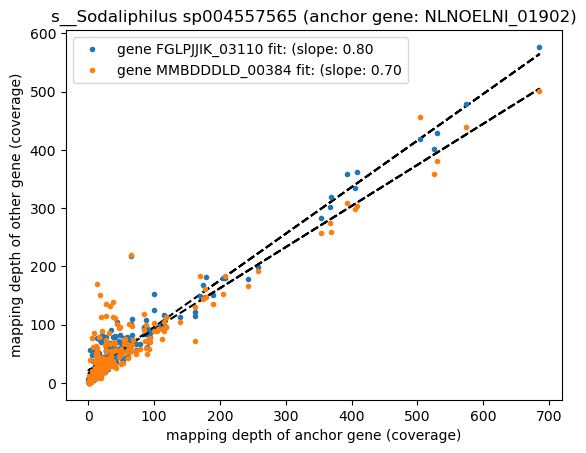

In [53]:
plot_genes_correlation(gene_df, 's__Sodaliphilus sp004557565')

s__Bariatricus sp004560705
found defined anchor gene CHOLCMOC_00863 for s__Bariatricus sp004560705


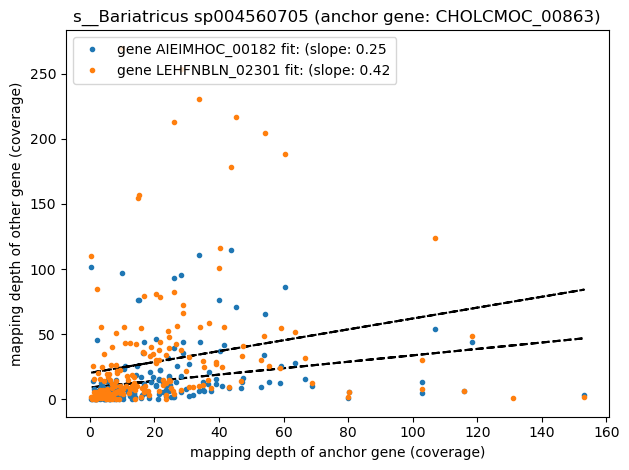

s__Colivicinus sp002299675
found defined anchor gene CJCMOHOO_00566 for s__Colivicinus sp002299675


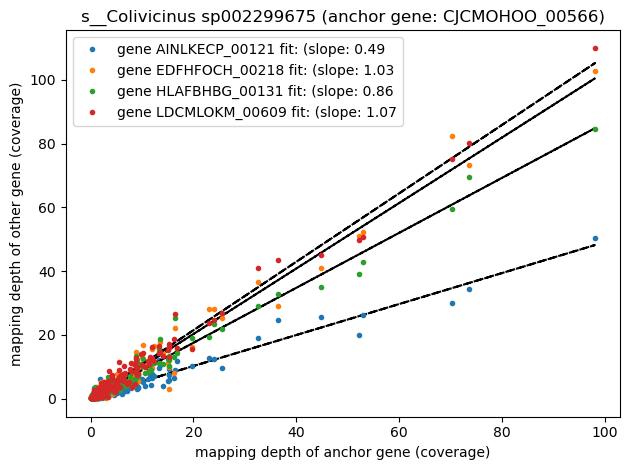

s__Cryptobacteroides sp000432655
found defined anchor gene FCPPOLBJ_01182 for s__Cryptobacteroides sp000432655


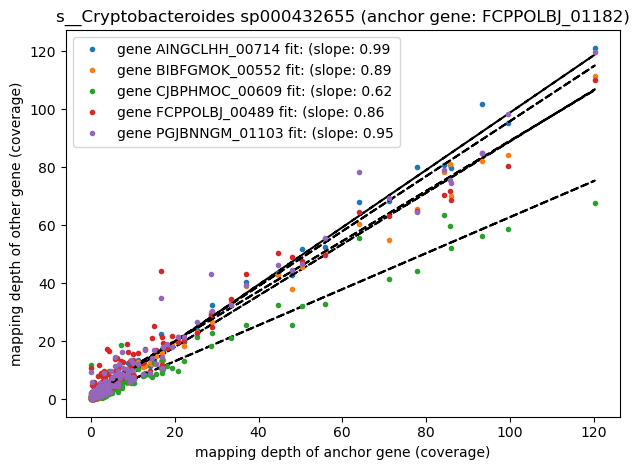

s__Cryptobacteroides sp000434935
found defined anchor gene JBPBJODD_00501 for s__Cryptobacteroides sp000434935


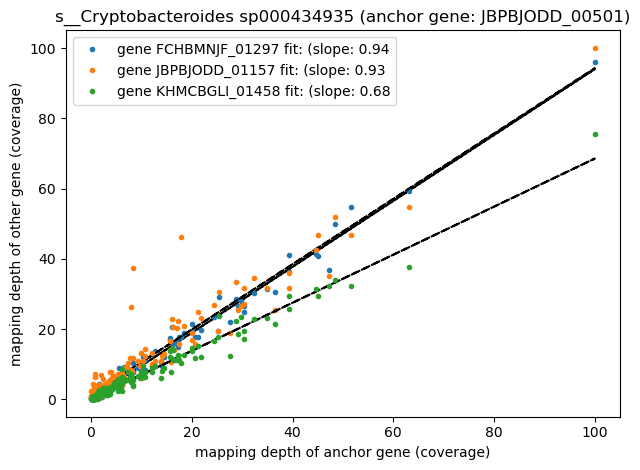

s__Cryptobacteroides sp034089285
found defined anchor gene PMGOFJOK_00542 for s__Cryptobacteroides sp034089285


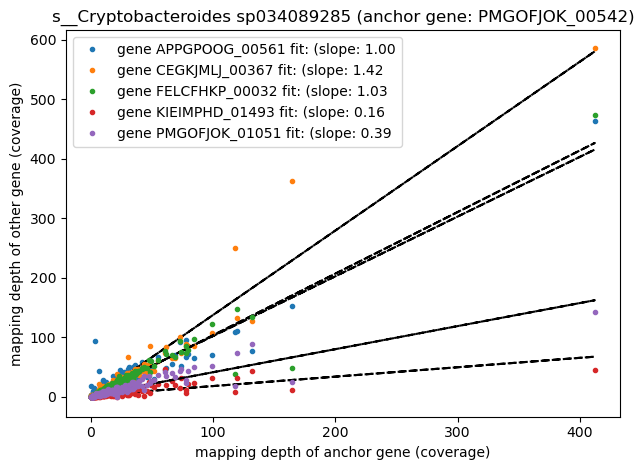

s__Cryptobacteroides sp900546925
found defined anchor gene OIGHMFGK_00345 for s__Cryptobacteroides sp900546925


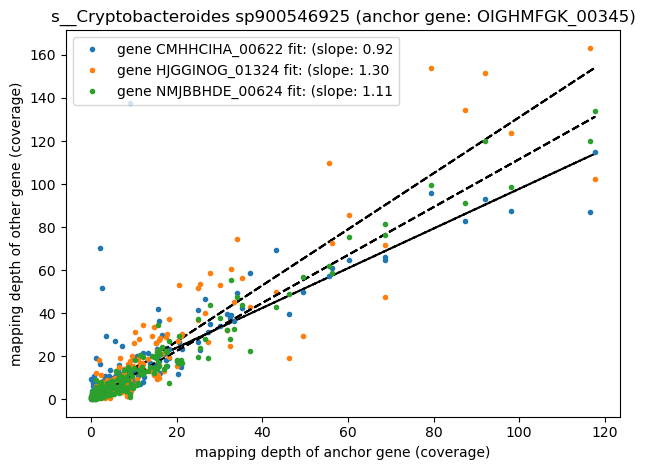

s__Fimisoma sp002320005
found defined anchor gene JBNOCHBL_00669 for s__Fimisoma sp002320005


/tmp/ipykernel_3874390/3040250097.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


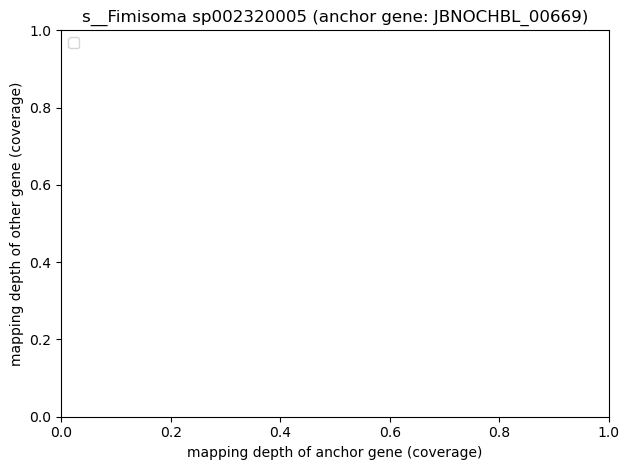

s__Floccifex porci
found defined anchor gene IIAENJBH_00799 for s__Floccifex porci


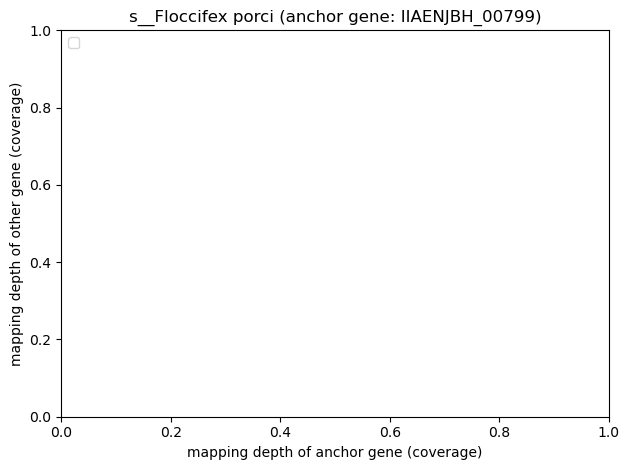

s__JALFVM01 sp022787145


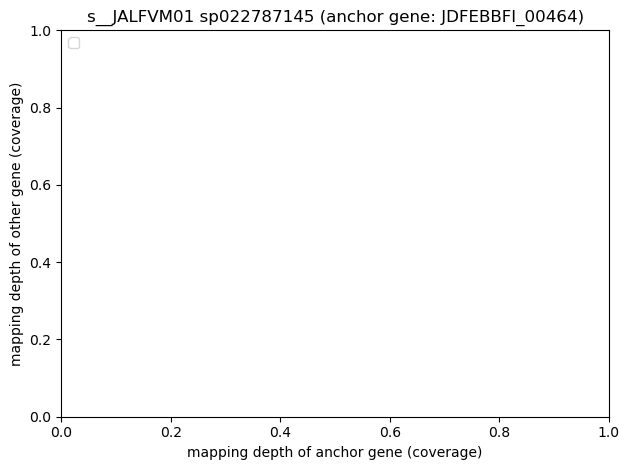

s__Lactobacillus amylovorus
found defined anchor gene OMBJBIHD_01711 for s__Lactobacillus amylovorus


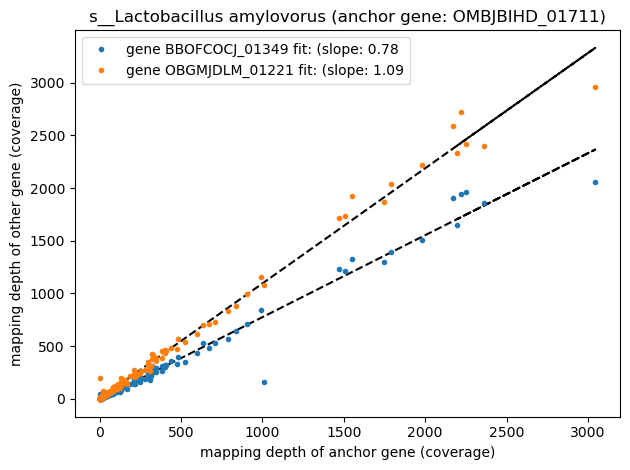

s__Mogibacterium_A kristiansenii
found defined anchor gene DKAPMIEG_00121 for s__Mogibacterium_A kristiansenii


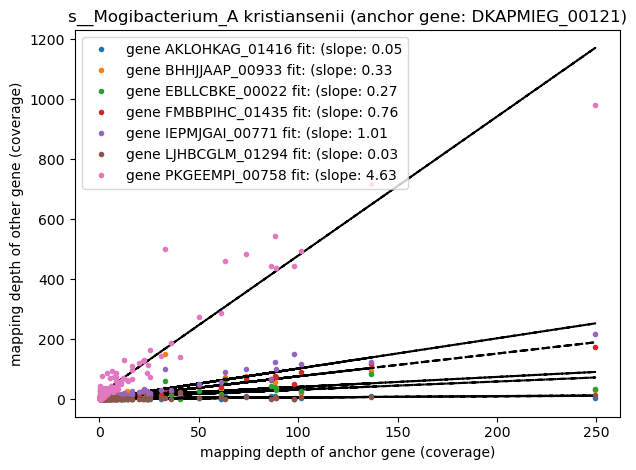

s__Ornithospirochaeta sp022785155
found defined anchor gene DEDCPOFE_00144 for s__Ornithospirochaeta sp022785155


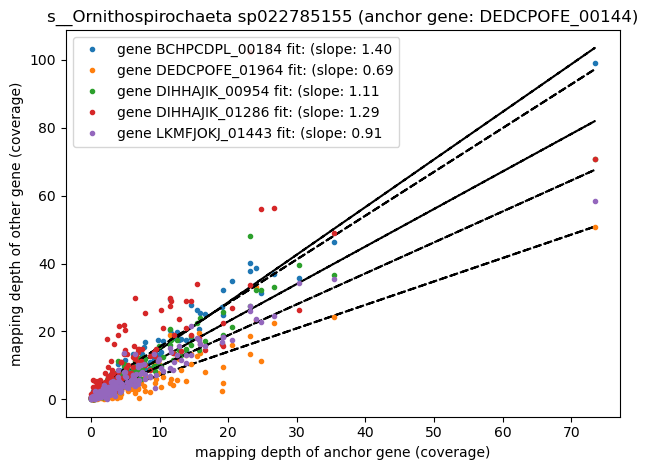

s__Phascolarctobacterium_A succinatutens
found defined anchor gene CNENGHLA_01260 for s__Phascolarctobacterium_A succinatutens


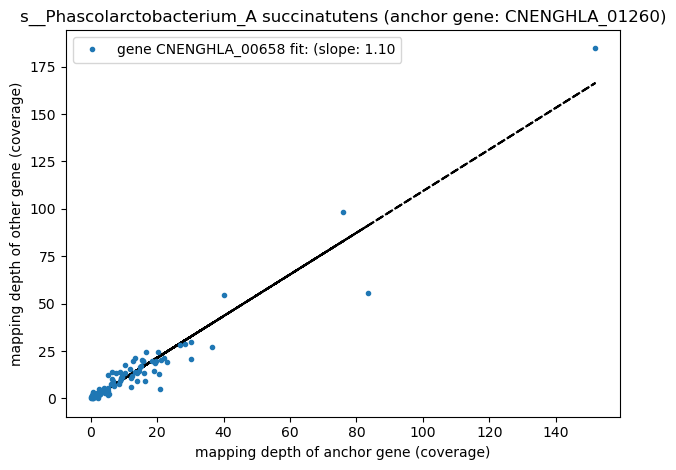

s__Prevotella sp000434975
found defined anchor gene APOLKBKG_00160 for s__Prevotella sp000434975


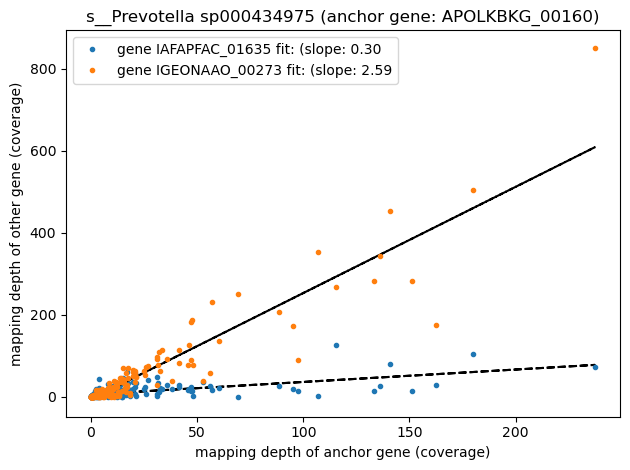

s__Prevotella sp002251295
found defined anchor gene GFALEAHI_01277 for s__Prevotella sp002251295


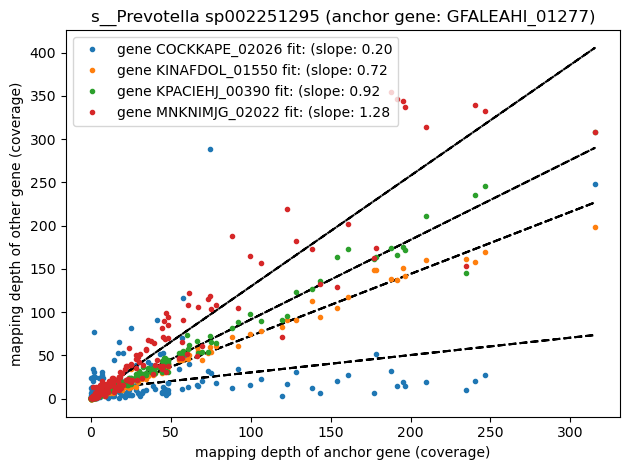

s__Sodaliphilus sp004557565
found defined anchor gene NLNOELNI_01902 for s__Sodaliphilus sp004557565


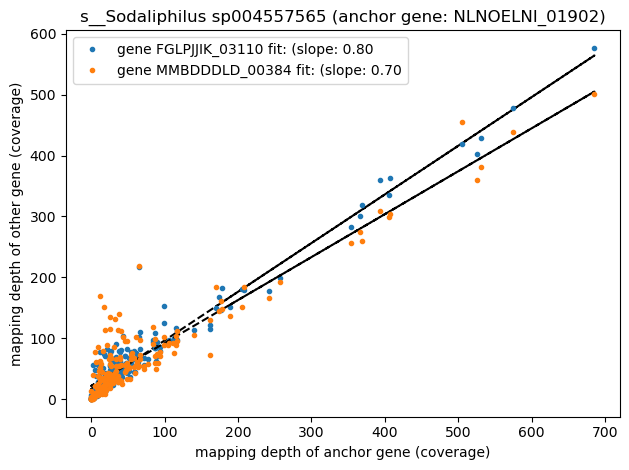

s__UBA2868 sp004552595
found defined anchor gene KMEHCMKH_00746 for s__UBA2868 sp004552595


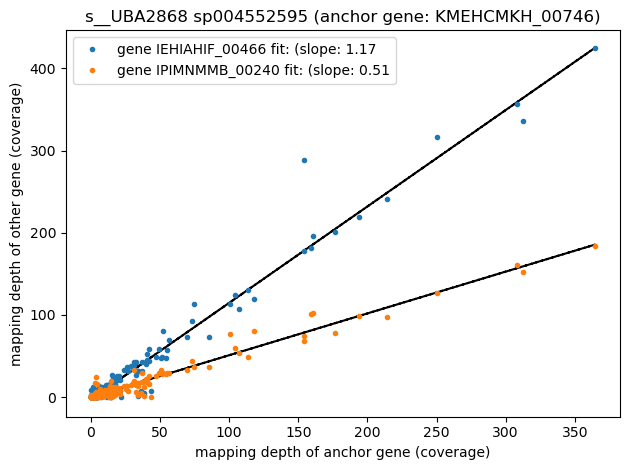

In [54]:
for species in sorted(gene_df['species'].unique()):
    print(species)
    plot_genes_correlation(gene_df, species)
    plt.tight_layout()
    plt.show()

found defined anchor gene OMBJBIHD_01711 for s__Lactobacillus amylovorus


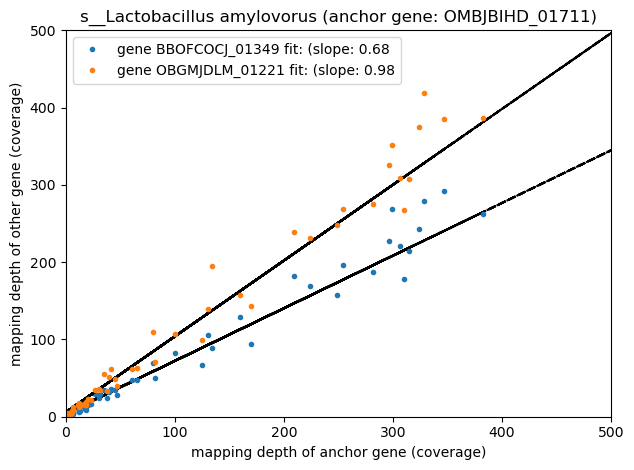

In [7]:
species = 's__Lactobacillus amylovorus'
plot_genes_correlation(gene_df, species)
plt.tight_layout()
plt.xlim(0, 500)
plt.ylim(0, 500)
plt.show()

In [55]:
gene_avg_df_XX = gene_df.group_by(["metag", "species"]).agg(
    pl.col("depth_all").mean(),
    pl.col("depth_cov").mean(),
)
gene_avg_df_XX

metag,species,depth_all,depth_cov
str,str,f64,f64
"""SRR11185232""","""s__Floccifex porci""",2.772186,2.85563
"""SRR11551369""","""s__Colivicinus sp002299675""",21.827759,23.222763
"""ERR3211906""","""s__Lactobacillus amylovorus""",0.79445,1.392995
"""ERR3211891""","""s__UBA2868 sp004552595""",1.158171,1.772133
"""SRR8960101""","""s__Ornithospirochaeta sp022785…",0.722373,2.328252
…,…,…,…
"""SRR17241658""","""s__Cryptobacteroides sp0340892…",18.93659,20.354151
"""SRR17241658""","""s__Fimisoma sp002320005""",4.325153,4.628009
"""SRR17241627""","""s__Mogibacterium_A kristiansen…",1.923704,NaN


## Can we correlate k-mer coverage with coverage from gene mapping?

Basically, yes!

Here we are evaluating our k-mer collector's curves of coverage (y axis) against mapping based coverage using the species-specific genes. If we get straight lines (and we do!) then we win!

I'm not entirely sure why the slopes vary tho. Working on it.

In [56]:
kmer_df = pl.read_parquet('../inputs.abundhist/kmer-coverage.parquet')

In [57]:
kmer_df = kmer_df.with_columns(
    pl.col("query_name").alias("species"),
    pl.col("match_name").alias("metag"),
    pl.col("depth").alias("depth_est"),
).select(["species", "metag", "depth_est"])
kmer_df

species,metag,depth_est
str,str,f64
"""s__Cryptobacteroides sp0004326…","""SRR11125436""",0.277108
"""s__Bariatricus sp004560705""","""SRR11125436""",0.651935
"""s__Floccifex porci""","""SRR11125436""",0.254813
"""s__Cryptobacteroides sp0340892…","""SRR11125436""",0.547788
"""s__Prevotella sp000434975""","""SRR11125436""",0.009389
…,…,…
"""s__Colivicinus sp002299675""","""ERR8314784""",2.321568
"""s__CAG-269 sp014846485""","""ERR8314784""",0.00441
"""s__UMGS1225 sp034086705""","""ERR8314784""",0.075952


## Compare mean gene expression with estimates

In [58]:
anchor_gene_df = gene_df.filter(pl.col("anchor") == 1)

In [59]:
combo_df = join2_df.join(anchor_gene_df, on=["species", "metag"], how="inner")
combo_df

species,metag,depth_est,gene,len,hits,breadth,depth_all,depth_cov,anchor,description
str,str,f64,str,i64,i64,f64,f64,f64,i64,str
"""s__Cryptobacteroides sp0004326…","""SRR12795775""",0.00107,"""FCPPOLBJ_01182""",2820,0,0.0,0.0,NaN,1,"""TonB-dependent receptor [Bacte…"
"""s__Sodaliphilus sp004557565""","""SRR12795775""",0.101183,"""NLNOELNI_01902""",1968,0,0.0,0.0,NaN,1,"""IG-like domain-containing prot…"
"""s__Prevotella sp002251295""","""SRR12795775""",0.009999,"""GFALEAHI_01277""",2526,0,0.0,0.0,NaN,1,"""YfnO"""
"""s__UBA2868 sp004552595""","""SRR12795775""",0.006191,"""KMEHCMKH_00746""",1083,0,0.0,0.0,NaN,1,"""multiple monosaccharide ABC tr…"
"""s__Lactobacillus amylovorus""","""SRR12795775""",122.116997,"""OMBJBIHD_01711""",1134,1127,0.993827,328.681658,330.723159,1,"""BLAST match to LD-transpeptida…"
…,…,…,…,…,…,…,…,…,…,…
"""s__Prevotella sp002251295""","""SRR17241500""",90.322689,"""GFALEAHI_01277""",2526,2512,0.994458,187.71536,188.761545,1,"""YfnO"""
"""s__Mogibacterium_A kristiansen…","""SRR17241500""",18.444262,"""DKAPMIEG_00121""",564,239,0.423759,0.83156,1.962343,1,"""BLAST match to isolate genome"""
"""s__Lactobacillus amylovorus""","""SRR17241500""",74.233176,"""OMBJBIHD_01711""",1134,1127,0.993827,229.016755,230.439219,1,"""BLAST match to LD-transpeptida…"


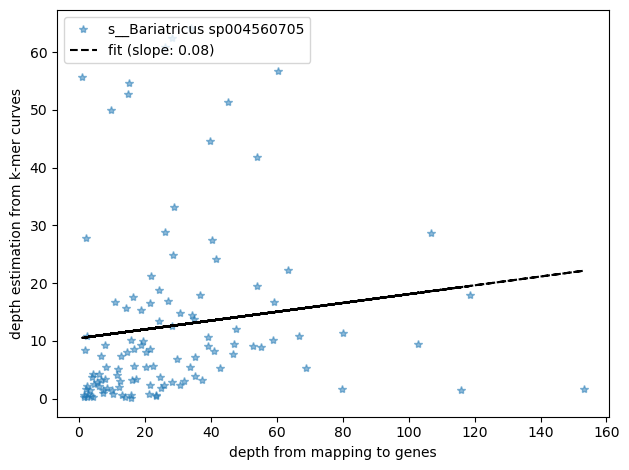

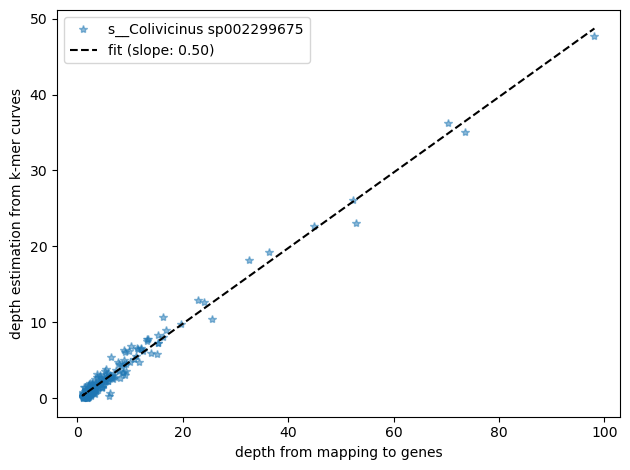

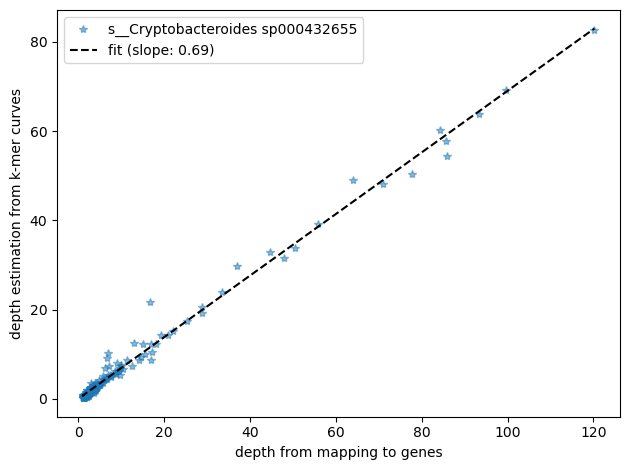

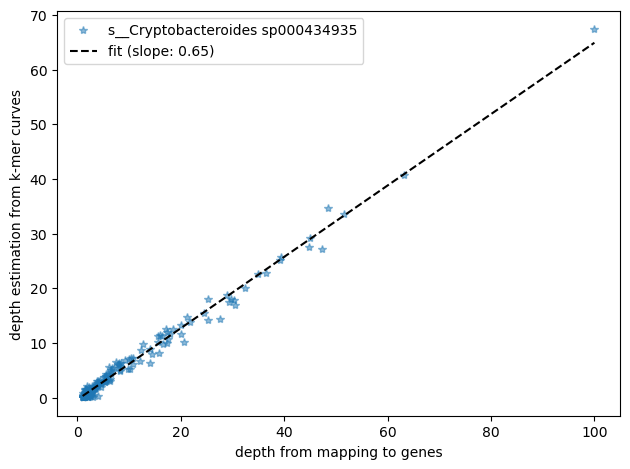

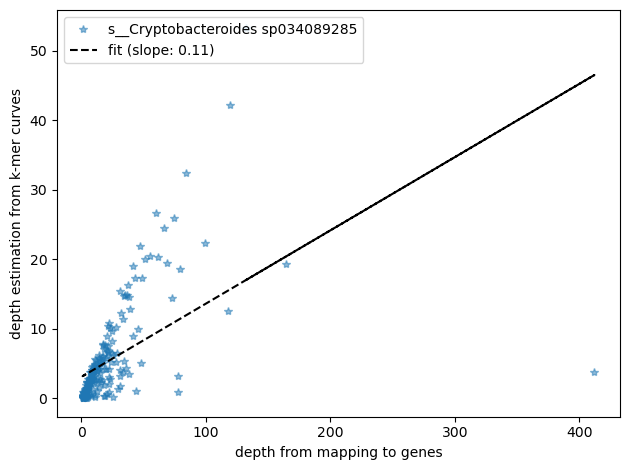

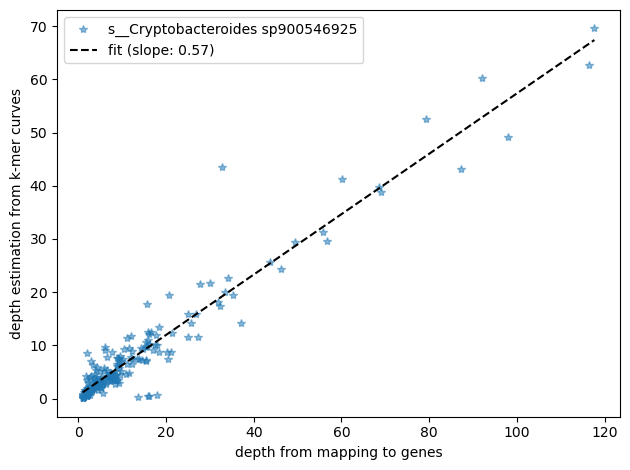

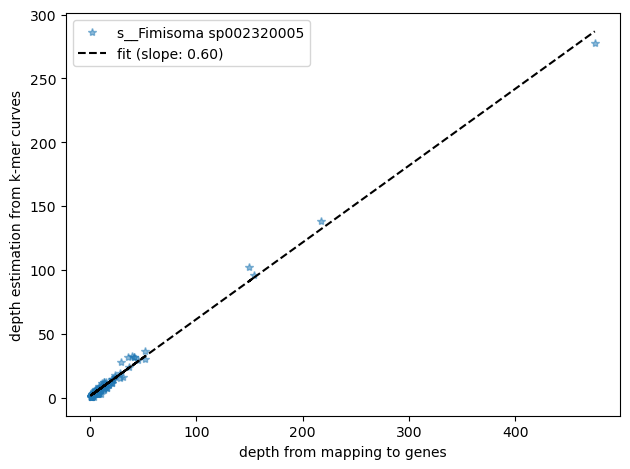

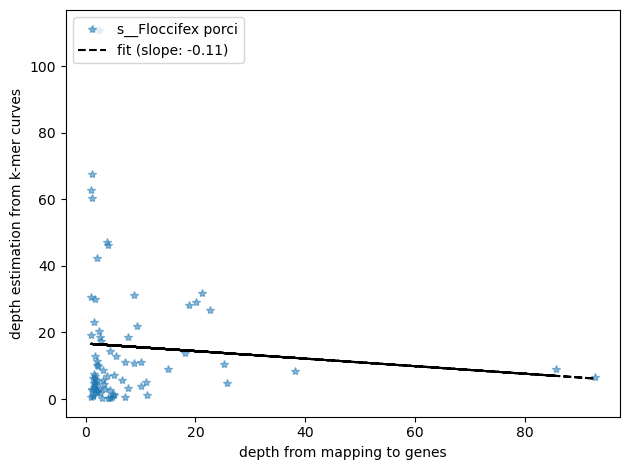

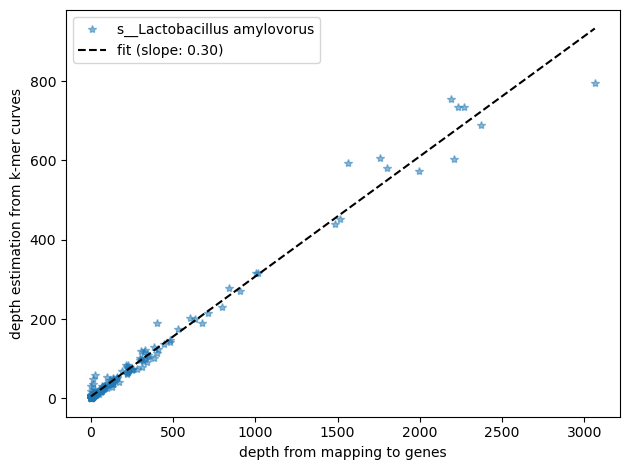

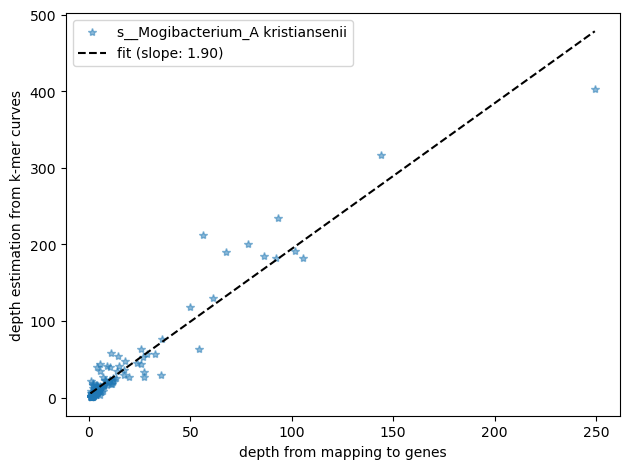

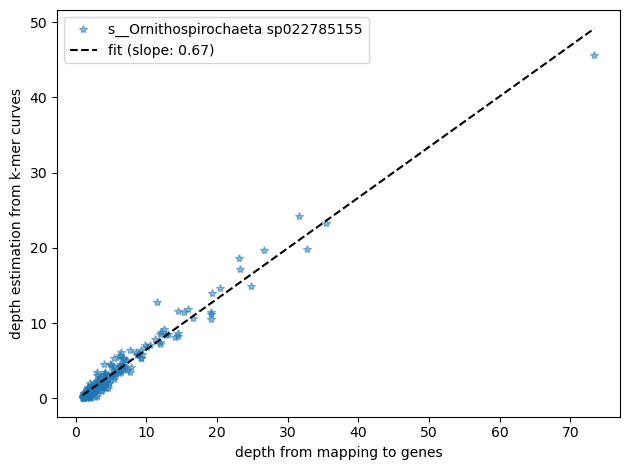

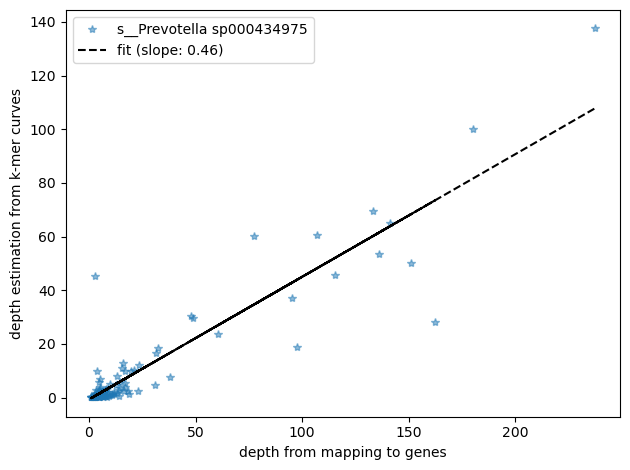

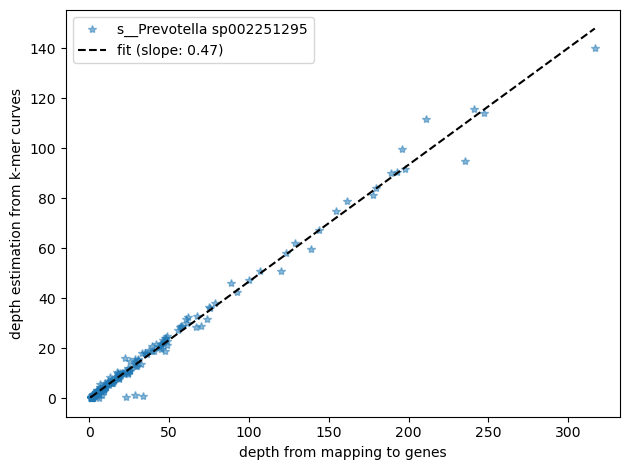

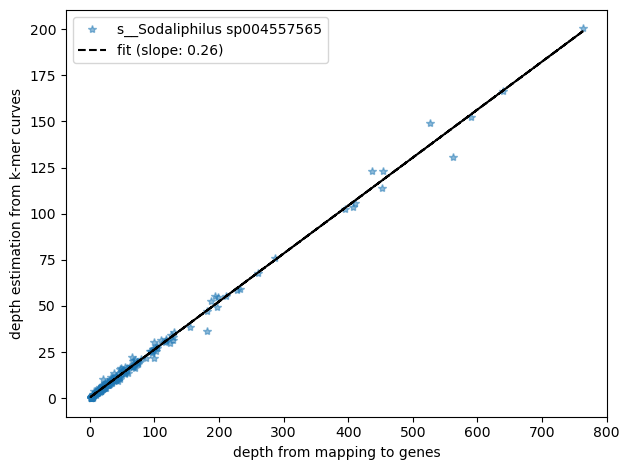

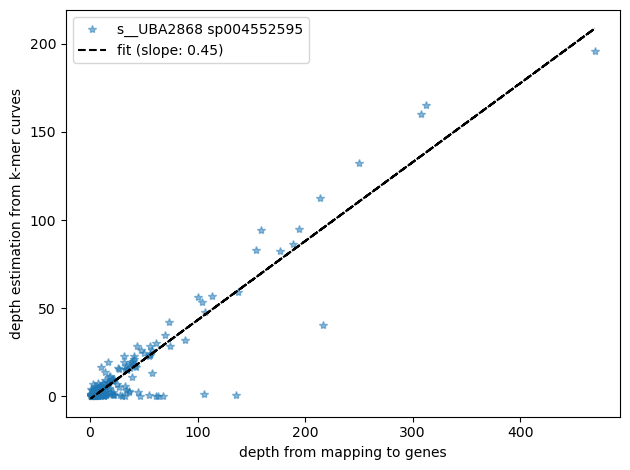

In [60]:
for species in sorted(combo_df['species'].unique()):
    xx_df = combo_df.filter(pl.col("species") == species).drop_nans().sort(by='depth_est')
    q95 = xx_df['depth_est'].to_list()[int(0.9 * len(xx_df))]
    xx2_df = xx_df.filter(
        pl.col("depth_est") < q95
    )
    x = xx_df['depth_cov']
    y = xx_df['depth_est']
    plt.plot(x, y, '*', alpha=0.5, label=species)

    coef = np.polyfit(x, y, 1)
    poly1d_fn = np.poly1d(coef) 
    plt.plot(x, poly1d_fn(x), '--k', label=f'fit (slope: {coef[0]:.2f})')
    
    #plt.xlim(0, 600)
    #plt.ylim(0, 200)
    plt.xlabel('depth from mapping to genes')
    plt.ylabel('depth estimation from k-mer curves')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

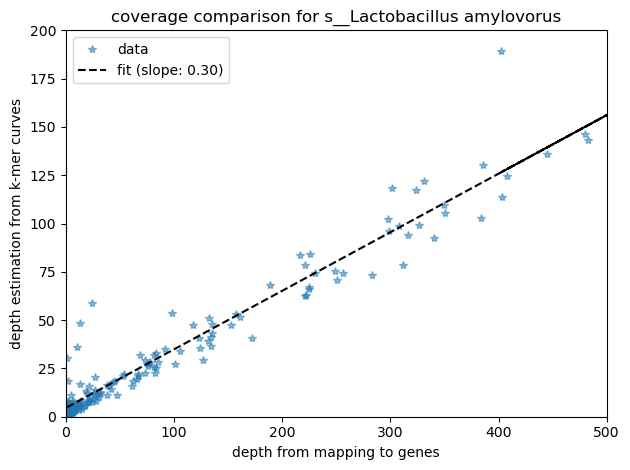

In [61]:
species = 's__Lactobacillus amylovorus'
xx_df = combo_df.filter(pl.col("species") == species).drop_nans().sort(by='depth_est')
q95 = xx_df['depth_est'].to_list()[int(0.9 * len(xx_df))]
xx2_df = xx_df.filter(
    pl.col("depth_est") < q95
)
x = xx_df['depth_cov']
y = xx_df['depth_est']
plt.plot(x, y, '*', alpha=0.5, label="data")

coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef) 
plt.plot(x, poly1d_fn(x), '--k', label=f'fit (slope: {coef[0]:.2f})')

plt.xlim(0, 500)
plt.ylim(0, 200)
plt.xlabel('depth from mapping to genes')
plt.ylabel('depth estimation from k-mer curves')
plt.title(f'coverage comparison for {species}')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

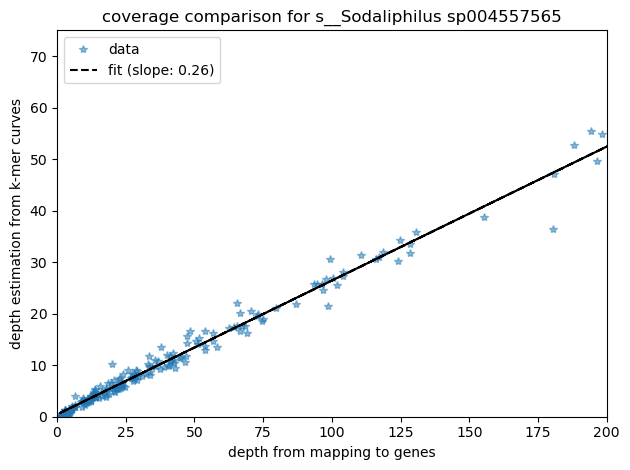

In [62]:
species = 's__Sodaliphilus sp004557565'
xx_df = combo_df.filter(pl.col("species") == species).drop_nans().sort(by='depth_est')
q95 = xx_df['depth_est'].to_list()[int(0.9 * len(xx_df))]
xx2_df = xx_df.filter(
    pl.col("depth_est") < q95
)
x = xx_df['depth_cov']
y = xx_df['depth_est']
plt.plot(x, y, '*', alpha=0.5, label="data")

coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef) 
plt.plot(x, poly1d_fn(x), '--k', label=f'fit (slope: {coef[0]:.2f})')

plt.xlim(0, 200)
plt.ylim(0, 75)
plt.xlabel('depth from mapping to genes')
plt.ylabel('depth estimation from k-mer curves')
plt.title(f'coverage comparison for {species}')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

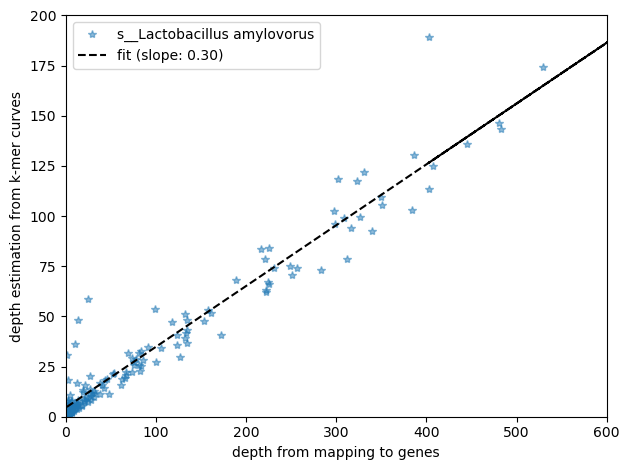

In [63]:
species = "s__Lactobacillus amylovorus"

xx_df = combo_df.filter(pl.col("species") == species).drop_nans().sort(by='depth_est')
q95 = xx_df['depth_est'].to_list()[int(0.9 * len(xx_df))]
xx2_df = xx_df.filter(
    pl.col("depth_est") < q95
)
x = xx_df['depth_cov']
y = xx_df['depth_est']
plt.plot(x, y, '*', alpha=0.5, label=species)

coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef) 
plt.plot(x, poly1d_fn(x), '--k', label=f'fit (slope: {coef[0]:.2f})')

plt.xlim(0, 600)
plt.ylim(0, 200)
plt.xlabel('depth from mapping to genes')
plt.ylabel('depth estimation from k-mer curves')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Compare k-mer coverage estimates with anchor genes only

In [64]:
anchor_gene_df = gene_df.filter(pl.col("anchor") == 1)
combo2_df = join2_df.join(anchor_gene_df, on=["species", "metag"], how="inner")
combo2_df

species,metag,depth_est,gene,len,hits,breadth,depth_all,depth_cov,anchor,description
str,str,f64,str,i64,i64,f64,f64,f64,i64,str
"""s__Cryptobacteroides sp0004326…","""SRR12795775""",0.00107,"""FCPPOLBJ_01182""",2820,0,0.0,0.0,NaN,1,"""TonB-dependent receptor [Bacte…"
"""s__Sodaliphilus sp004557565""","""SRR12795775""",0.101183,"""NLNOELNI_01902""",1968,0,0.0,0.0,NaN,1,"""IG-like domain-containing prot…"
"""s__Prevotella sp002251295""","""SRR12795775""",0.009999,"""GFALEAHI_01277""",2526,0,0.0,0.0,NaN,1,"""YfnO"""
"""s__UBA2868 sp004552595""","""SRR12795775""",0.006191,"""KMEHCMKH_00746""",1083,0,0.0,0.0,NaN,1,"""multiple monosaccharide ABC tr…"
"""s__Lactobacillus amylovorus""","""SRR12795775""",122.116997,"""OMBJBIHD_01711""",1134,1127,0.993827,328.681658,330.723159,1,"""BLAST match to LD-transpeptida…"
…,…,…,…,…,…,…,…,…,…,…
"""s__Prevotella sp002251295""","""SRR17241500""",90.322689,"""GFALEAHI_01277""",2526,2512,0.994458,187.71536,188.761545,1,"""YfnO"""
"""s__Mogibacterium_A kristiansen…","""SRR17241500""",18.444262,"""DKAPMIEG_00121""",564,239,0.423759,0.83156,1.962343,1,"""BLAST match to isolate genome"""
"""s__Lactobacillus amylovorus""","""SRR17241500""",74.233176,"""OMBJBIHD_01711""",1134,1127,0.993827,229.016755,230.439219,1,"""BLAST match to LD-transpeptida…"


In [65]:
combo2_df['species'].unique().to_list()

['s__Cryptobacteroides sp034089285',
 's__Lactobacillus amylovorus',
 's__Floccifex porci',
 's__Fimisoma sp002320005',
 's__Ornithospirochaeta sp022785155',
 's__Prevotella sp000434975',
 's__Cryptobacteroides sp000434935',
 's__Prevotella sp002251295',
 's__Mogibacterium_A kristiansenii',
 's__Bariatricus sp004560705',
 's__Colivicinus sp002299675',
 's__Cryptobacteroides sp000432655',
 's__Sodaliphilus sp004557565',
 's__UBA2868 sp004552595',
 's__Cryptobacteroides sp900546925']

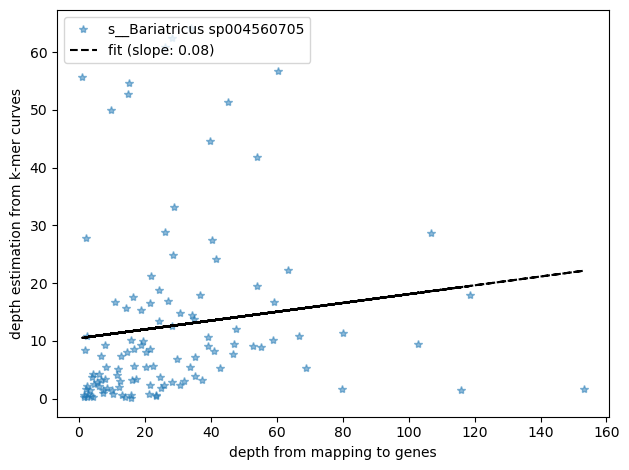

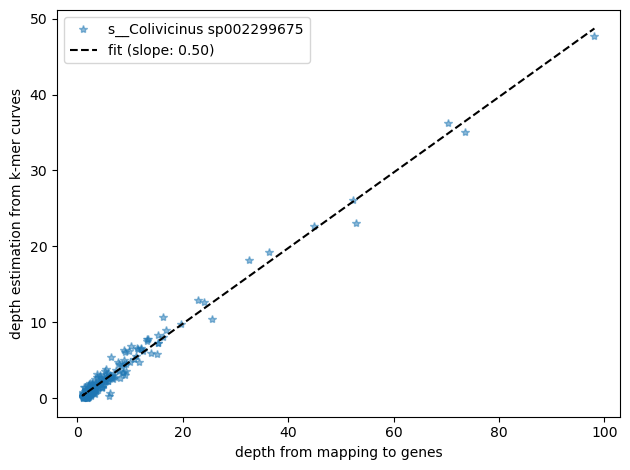

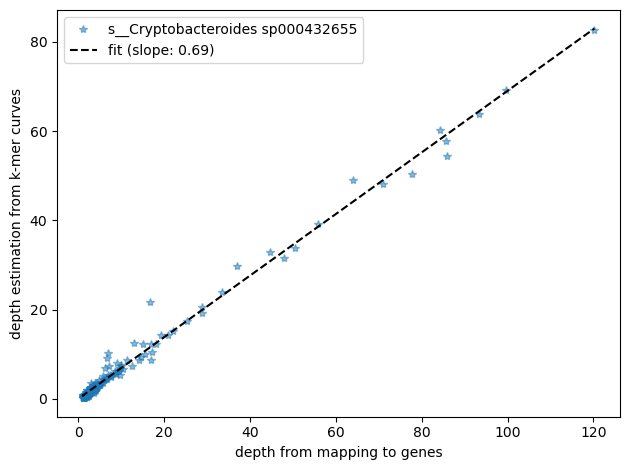

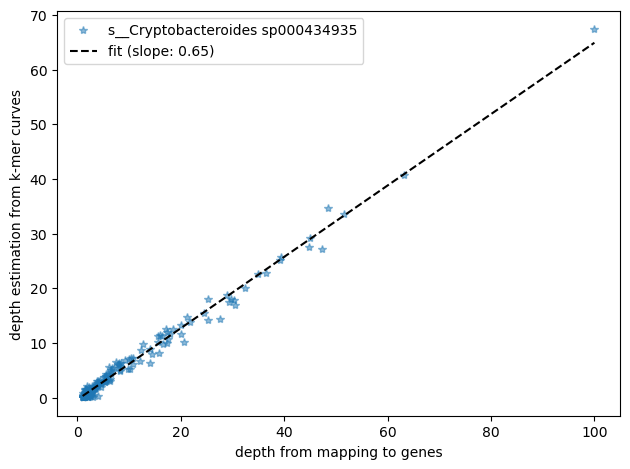

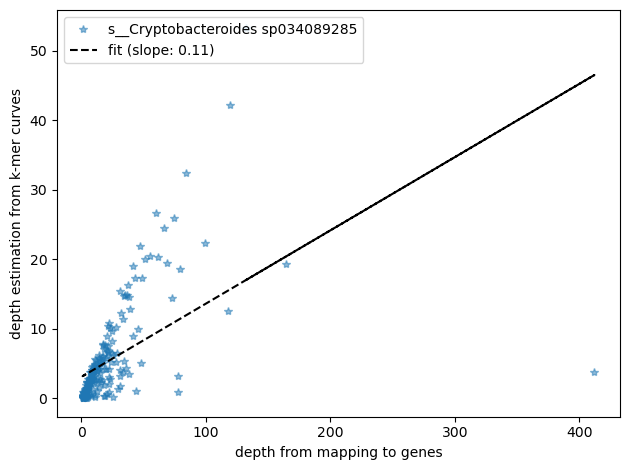

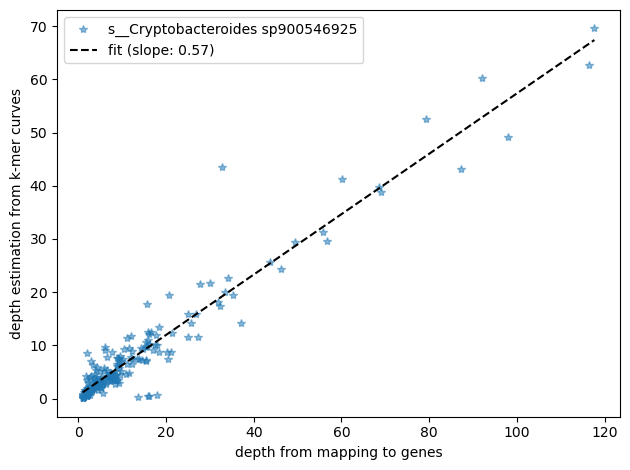

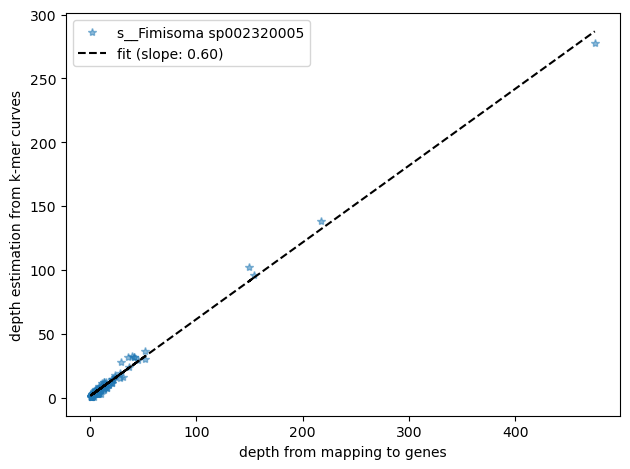

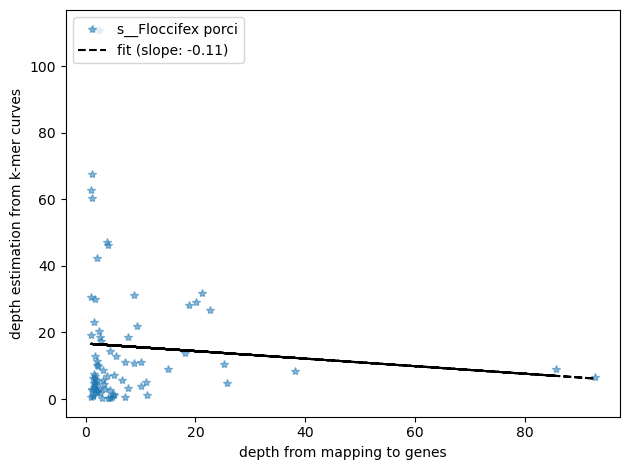

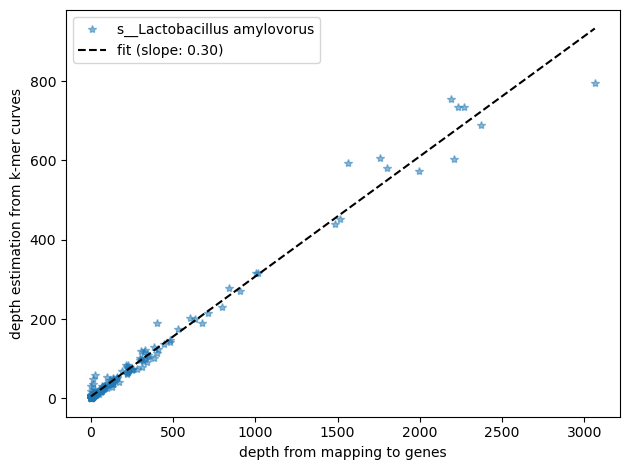

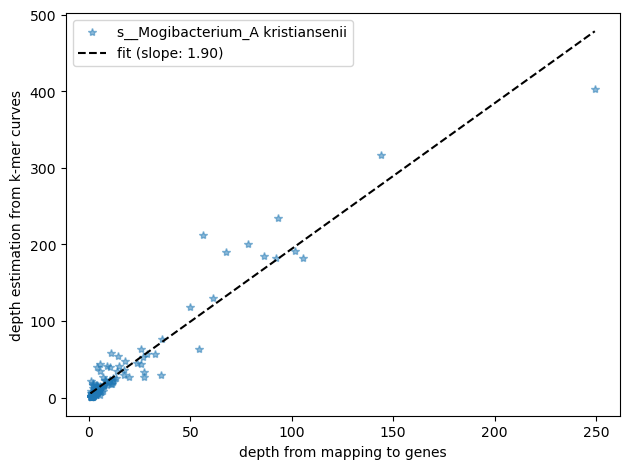

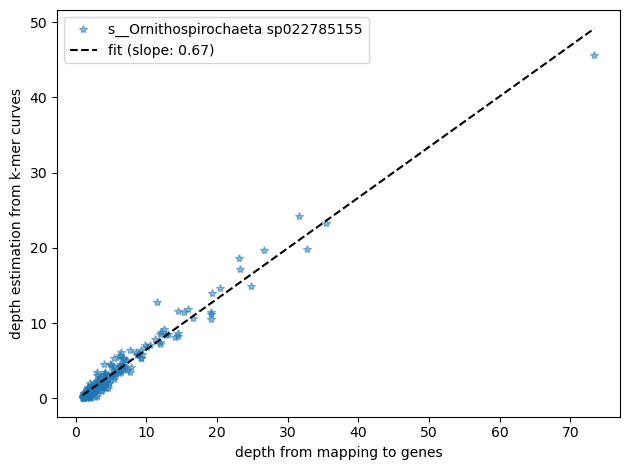

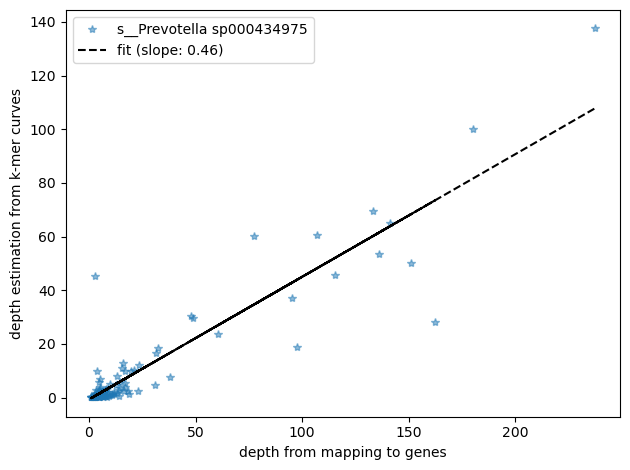

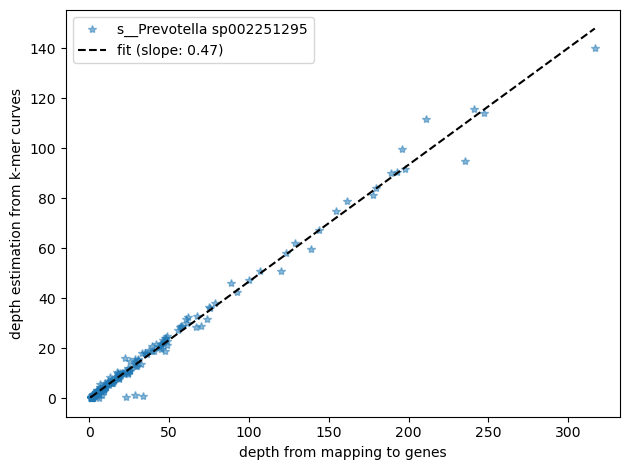

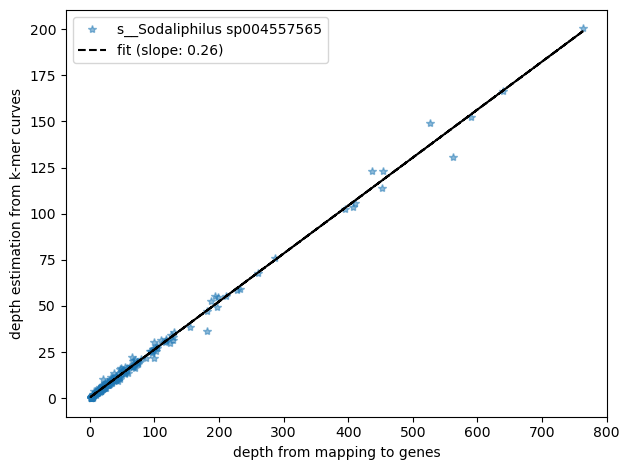

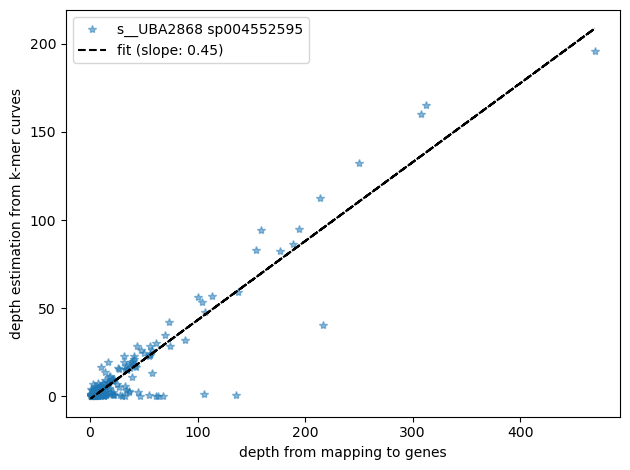

In [66]:
ANCHOR_FIT_PARAMS = {}

for species in sorted(combo2_df['species'].unique()):
    xx_df = combo2_df.filter(pl.col("species") == species).drop_nans().sort(by='depth_est')
    q95 = xx_df['depth_est'].to_list()[int(0.9 * len(xx_df))]
    xx2_df = xx_df.filter(
        pl.col("depth_est") < q95
    )
    x = xx_df['depth_cov']
    y = xx_df['depth_est']
    plt.plot(x, y, '*', alpha=0.5, label=species)

    coef = np.polyfit(x, y, 1)
    poly1d_fn = np.poly1d(coef) 
    plt.plot(x, poly1d_fn(x), '--k', label=f'fit (slope: {coef[0]:.2f})')

    ANCHOR_FIT_PARAMS[species] = coef[0]
    
    #plt.xlim(0, 600)
    #plt.ylim(0, 200)
    plt.xlabel('depth from mapping to genes')
    plt.ylabel('depth estimation from k-mer curves')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

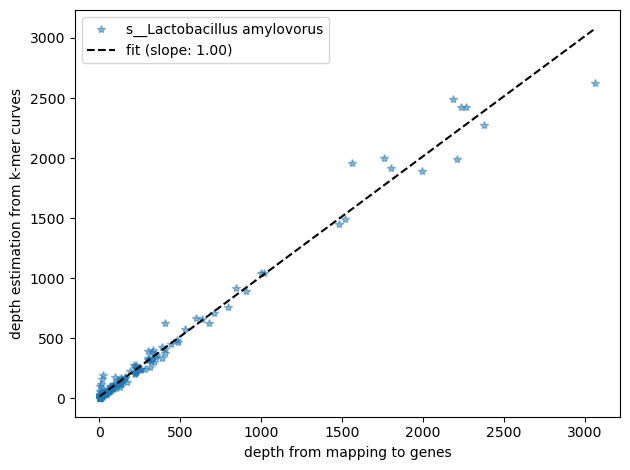

In [67]:
species = 's__Lactobacillus amylovorus'
fit_slope = ANCHOR_FIT_PARAMS[species]
xx_df = combo2_df.filter(pl.col("species") == species).drop_nans().sort(by='depth_est')
q95 = xx_df['depth_est'].to_list()[int(0.9 * len(xx_df))]
xx2_df = xx_df.filter(
    pl.col("depth_est") < q95
)
x = xx_df['depth_cov']
y = xx_df['depth_est'] / fit_slope
plt.plot(x, y, '*', alpha=0.5, label=species)

coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef) 
plt.plot(x, poly1d_fn(x), '--k', label=f'fit (slope: {coef[0]:.2f})')

ANCHOR_FIT_PARAMS[species] = coef[0]

#plt.xlim(0, 600)
#plt.ylim(0, 200)
plt.xlabel('depth from mapping to genes')
plt.ylabel('depth estimation from k-mer curves')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [68]:
species = 's__Lactobacillus amylovorus'
fit_slope = ANCHOR_FIT_PARAMS[species]

k2_df = (kmer_df.filter(pl.col('species') == species).with_columns(adj_depth=pl.col('depth') / fit_slope))

plt.plot(k2_df['adj_depth'], k2_df['intersect_bp'], '*', alpha=0.5)
plt.xlim(0, 5)
plt.ylim(0, 0.6e6)
plt.xlabel('corrected k-mer coverage')
plt.ylabel('intersect_bp (containment)')
plt.title(f'est cov of {species} in 3,216 metagenomes')

n_below = len(k2_df.filter(pl.col('adj_depth') < 1))
print(n_below / len(k2_df))

ColumnNotFoundError: unable to find column "depth"; valid columns: ["species", "metag", "depth_est"]

In [ ]:
species = 's__Sodaliphilus sp004557565'
fit_slope = ANCHOR_FIT_PARAMS[species]

k2_df = (kmer_df.filter(pl.col('species') == species).with_columns(adj_depth=pl.col('depth') / fit_slope))
k2_df

plt.plot(k2_df['adj_depth'], k2_df['intersect_bp'], '*', alpha=0.5)
plt.xlim(0, 5)
plt.ylim(0, 1.5e6)
plt.xlabel('corrected k-mer coverage')
plt.ylabel('intersect_bp (containment)')
plt.title(f'est cov of {species} in 3,216 metagenomes')

n_below = len(k2_df.filter(pl.col('adj_depth') < 1))
print(n_below / len(k2_df))

## Extract some specific metagenomes...

In [ ]:
combo_df.filter(pl.col('species') == 's__Lactobacillus amylovorus').sort(by='depth_est').tail()['metag'].to_list()

In [ ]:
SS = 's__Prevotella sp000434975'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

In [69]:
SS = 's__Lactobacillus amylovorus'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

shape: (10, 11)
┌────────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬────────┬───────────┐
│ species    ┆ metag      ┆ depth_est ┆ gene      ┆ … ┆ depth_all ┆ depth_cov ┆ anchor ┆ descripti │
│ ---        ┆ ---        ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---    ┆ on        │
│ str        ┆ str        ┆ f64       ┆ str       ┆   ┆ f64       ┆ f64       ┆ i64    ┆ ---       │
│            ┆            ┆           ┆           ┆   ┆           ┆           ┆        ┆ str       │
╞════════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪════════╪═══════════╡
│ s__Lactoba ┆ SRR1724164 ┆ 22.597528 ┆ OMBJBIHD_ ┆ … ┆ 81.250441 ┆ 82.11943  ┆ 1      ┆ BLAST     │
│ cillus     ┆ 2          ┆           ┆ 01711     ┆   ┆           ┆           ┆        ┆ match to  │
│ amylovorus ┆            ┆           ┆           ┆   ┆           ┆           ┆        ┆ LD-transp │
│            ┆            ┆           ┆           ┆   ┆           ┆        

['SRR17241642',
 'SRR12799828',
 'SRR8960608',
 'SRR17241499',
 'SRR8960438',
 'SRR14812372',
 'SRR17241565',
 'SRR8960383',
 'SRR8960441',
 'SRR11185230']

In [70]:
SS = 's__Mogibacterium_A kristiansenii'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

shape: (10, 11)
┌────────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬────────┬───────────┐
│ species    ┆ metag      ┆ depth_est ┆ gene      ┆ … ┆ depth_all ┆ depth_cov ┆ anchor ┆ descripti │
│ ---        ┆ ---        ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---    ┆ on        │
│ str        ┆ str        ┆ f64       ┆ str       ┆   ┆ f64       ┆ f64       ┆ i64    ┆ ---       │
│            ┆            ┆           ┆           ┆   ┆           ┆           ┆        ┆ str       │
╞════════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪════════╪═══════════╡
│ s__Mogibac ┆ SRR1724164 ┆ 5.636932  ┆ DKAPMIEG_ ┆ … ┆ 0.093972  ┆ 1.0       ┆ 1      ┆ BLAST     │
│ terium_A   ┆ 0          ┆           ┆ 00121     ┆   ┆           ┆           ┆        ┆ match to  │
│ kristianse ┆            ┆           ┆           ┆   ┆           ┆           ┆        ┆ isolate   │
│ n…         ┆            ┆           ┆           ┆   ┆           ┆        

['SRR17241640',
 'SRR8960101',
 'SRR17241494',
 'SRR8960205',
 'SRR11185241',
 'SRR8960608',
 'SRR8960176',
 'SRR17241614',
 'SRR11185237',
 'SRR11185246']

In [26]:
SS = 's__Prevotella sp002251295'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

shape: (10, 5)
┌───────────────────────────┬─────────────┬───────────┬───────────┬───────────┐
│ species                   ┆ metag       ┆ depth_est ┆ depth_all ┆ depth_cov │
│ ---                       ┆ ---         ┆ ---       ┆ ---       ┆ ---       │
│ str                       ┆ str         ┆ f64       ┆ f64       ┆ f64       │
╞═══════════════════════════╪═════════════╪═══════════╪═══════════╪═══════════╡
│ s__Prevotella sp002251295 ┆ SRR8960491  ┆ 0.617959  ┆ 2.161036  ┆ 2.781661  │
│ s__Prevotella sp002251295 ┆ SRR5241534  ┆ 1.199921  ┆ 2.229826  ┆ 2.580083  │
│ s__Prevotella sp002251295 ┆ ERR1135213  ┆ 2.549831  ┆ 4.788922  ┆ 5.065131  │
│ s__Prevotella sp002251295 ┆ ERR3211839  ┆ 9.056734  ┆ 14.201709 ┆ 14.801384 │
│ s__Prevotella sp002251295 ┆ ERR3211879  ┆ 9.736689  ┆ 15.879577 ┆ 16.419793 │
│ s__Prevotella sp002251295 ┆ ERR3211876  ┆ 10.278653 ┆ 17.776974 ┆ 18.440059 │
│ s__Prevotella sp002251295 ┆ SRR14369134 ┆ 13.891081 ┆ 25.388484 ┆ 25.993348 │
│ s__Prevotella sp0022512

['SRR8960491',
 'SRR5241534',
 'ERR1135213',
 'ERR3211839',
 'ERR3211879',
 'ERR3211876',
 'SRR14369134',
 'ERR3211783',
 'SRR14369306',
 'SRR11489781']

In [27]:
SS = 's__Cryptobacteroides sp900546925'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

shape: (10, 5)
┌─────────────────────────────────┬─────────────┬───────────┬───────────┬───────────┐
│ species                         ┆ metag       ┆ depth_est ┆ depth_all ┆ depth_cov │
│ ---                             ┆ ---         ┆ ---       ┆ ---       ┆ ---       │
│ str                             ┆ str         ┆ f64       ┆ f64       ┆ f64       │
╞═════════════════════════════════╪═════════════╪═══════════╪═══════════╪═══════════╡
│ s__Cryptobacteroides sp9005469… ┆ SRR17241596 ┆ 1.429369  ┆ 1.926641  ┆ 4.391577  │
│ s__Cryptobacteroides sp9005469… ┆ ERR3211812  ┆ 2.103742  ┆ 3.301391  ┆ 3.365928  │
│ s__Cryptobacteroides sp9005469… ┆ ERR3211974  ┆ 2.974776  ┆ 4.802559  ┆ 4.842193  │
│ s__Cryptobacteroides sp9005469… ┆ ERR8314767  ┆ 4.395857  ┆ 7.608749  ┆ 7.627002  │
│ s__Cryptobacteroides sp9005469… ┆ ERR8314788  ┆ 4.520936  ┆ 8.945554  ┆ 8.963083  │
│ s__Cryptobacteroides sp9005469… ┆ ERR3211971  ┆ 5.166676  ┆ 7.126344  ┆ 7.126344  │
│ s__Cryptobacteroides sp9005469… ┆ SRR

['SRR17241596',
 'ERR3211812',
 'ERR3211974',
 'ERR8314767',
 'ERR8314788',
 'ERR3211971',
 'SRR10209683',
 'SRR11551383',
 'SRR14369219',
 'SRR17241485']

In [28]:
SS = 's__Sodaliphilus sp004557565'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

shape: (10, 5)
┌─────────────────────────────┬─────────────┬───────────┬────────────┬────────────┐
│ species                     ┆ metag       ┆ depth_est ┆ depth_all  ┆ depth_cov  │
│ ---                         ┆ ---         ┆ ---       ┆ ---        ┆ ---        │
│ str                         ┆ str         ┆ f64       ┆ f64        ┆ f64        │
╞═════════════════════════════╪═════════════╪═══════════╪════════════╪════════════╡
│ s__Sodaliphilus sp004557565 ┆ SRR11125534 ┆ 1.304597  ┆ 3.34624    ┆ 3.710039   │
│ s__Sodaliphilus sp004557565 ┆ SRR11805642 ┆ 2.684251  ┆ 15.207019  ┆ 15.628958  │
│ s__Sodaliphilus sp004557565 ┆ ERR8314743  ┆ 3.120499  ┆ 31.701346  ┆ 32.401585  │
│ s__Sodaliphilus sp004557565 ┆ ERR1135349  ┆ 5.685736  ┆ 52.832953  ┆ 53.141096  │
│ s__Sodaliphilus sp004557565 ┆ ERR3211891  ┆ 6.621264  ┆ 27.032605  ┆ 27.117047  │
│ s__Sodaliphilus sp004557565 ┆ ERR8314788  ┆ 7.726397  ┆ 58.005755  ┆ 58.005755  │
│ s__Sodaliphilus sp004557565 ┆ ERR3211929  ┆ 9.896855  ┆ 33.

['SRR11125534',
 'SRR11805642',
 'ERR8314743',
 'ERR1135349',
 'ERR3211891',
 'ERR8314788',
 'ERR3211929',
 'ERR1135303',
 'SRR10209683',
 'SRR16235699']

In [29]:
SS = 's__Colivicinus sp002299675'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(SS, combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

shape: (10, 5)
┌────────────────────────────┬─────────────┬───────────┬───────────┬───────────┐
│ species                    ┆ metag       ┆ depth_est ┆ depth_all ┆ depth_cov │
│ ---                        ┆ ---         ┆ ---       ┆ ---       ┆ ---       │
│ str                        ┆ str         ┆ f64       ┆ f64       ┆ f64       │
╞════════════════════════════╪═════════════╪═══════════╪═══════════╪═══════════╡
│ s__Colivicinus sp002299675 ┆ SRR5241534  ┆ 0.35054   ┆ 0.591697  ┆ 1.389203  │
│ s__Colivicinus sp002299675 ┆ ERR3211906  ┆ 0.406942  ┆ 0.509634  ┆ 1.380874  │
│ s__Colivicinus sp002299675 ┆ SRR5240744  ┆ 0.541578  ┆ 0.864331  ┆ 1.685932  │
│ s__Colivicinus sp002299675 ┆ ERR1135346  ┆ 1.258426  ┆ 1.964236  ┆ 2.44375   │
│ s__Colivicinus sp002299675 ┆ SRR17241663 ┆ 1.435515  ┆ 2.773938  ┆ 3.491313  │
│ s__Colivicinus sp002299675 ┆ SRR10209667 ┆ 1.498588  ┆ 2.781794  ┆ 3.253785  │
│ s__Colivicinus sp002299675 ┆ SRR12795793 ┆ 2.031676  ┆ 3.41736   ┆ 4.142902  │
│ s__Colivici

('s__Colivicinus sp002299675',
 ['SRR5241534',
  'ERR3211906',
  'SRR5240744',
  'ERR1135346',
  'SRR17241663',
  'SRR10209667',
  'SRR12795793',
  'ERR8314733',
  'SRR11489783',
  'SRR11551383'])

In [30]:
SS = 's__Ornithospirochaeta sp022785155'

with pl.Config(tbl_rows=-1):
    print((combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est'))
         )

(SS, combo_df
            .filter(pl.col('species') == SS)
            .drop_nans()
            .sort(by='depth_est')
            .tail(100)
            .sample(10, seed=42)
            .sort(by='depth_est')
            ['metag'].to_list())

shape: (10, 5)
┌─────────────────────────────────┬─────────────┬───────────┬───────────┬───────────┐
│ species                         ┆ metag       ┆ depth_est ┆ depth_all ┆ depth_cov │
│ ---                             ┆ ---         ┆ ---       ┆ ---       ┆ ---       │
│ str                             ┆ str         ┆ f64       ┆ f64       ┆ f64       │
╞═════════════════════════════════╪═════════════╪═══════════╪═══════════╪═══════════╡
│ s__Ornithospirochaeta sp022785… ┆ ERR1135273  ┆ 0.424724  ┆ 0.699943  ┆ 1.438457  │
│ s__Ornithospirochaeta sp022785… ┆ ERR3211801  ┆ 0.617664  ┆ 0.855113  ┆ 1.565639  │
│ s__Ornithospirochaeta sp022785… ┆ SRR18048904 ┆ 0.959609  ┆ 1.614607  ┆ 2.232149  │
│ s__Ornithospirochaeta sp022785… ┆ ERR8314788  ┆ 1.970795  ┆ 3.797618  ┆ 4.32943   │
│ s__Ornithospirochaeta sp022785… ┆ SRR8960625  ┆ 2.045934  ┆ 3.583411  ┆ 3.846894  │
│ s__Ornithospirochaeta sp022785… ┆ ERR1135213  ┆ 2.174561  ┆ 4.597405  ┆ 4.859983  │
│ s__Ornithospirochaeta sp022785… ┆ ERR

('s__Ornithospirochaeta sp022785155',
 ['ERR1135273',
  'ERR3211801',
  'SRR18048904',
  'ERR8314788',
  'SRR8960625',
  'ERR1135213',
  'ERR3211929',
  'ERR1135304',
  'SRR11489781',
  'SRR11489783'])

## Plot some abundance histograms

In [31]:
from sklearn.neighbors import KernelDensity
from scipy.signal import find_peaks

def find_rightmost_peak(abunds, counter, *, verbose=False):
    abunds = list(abunds)
    counts_dist = list(counter.items())
    sum_hist = sum(counter.values())

    sofar = 0
    for k, v in sorted(counts_dist):
        sofar += v
        if sofar >= 0.99*sum_hist:
            max_range = k
            break

    if verbose:
        print(f"max_range: {max_range}, sum_hist: {sum_hist}, sofar: {sofar}")
        print(max_range, len(abunds), max(abunds))

    arr = np.array(abunds)
    arr = arr[(arr >= 5)].reshape(-1, 1)

    kde = KernelDensity(kernel="gaussian", bandwidth=20).fit(arr)

    x = np.linspace(0, max_range, max_range)
    y = kde.score_samples(x.reshape(-1, 1))

    yl = np.exp(y)

    rightmost = 0
    i = 0
    xx = find_peaks(yl, width=20)[0]
    if verbose:
        print(xx)
    for i in xx:
        xval = x[i]
        if xval > max_range:
            if verbose:
                print('XXX2', xval, max_range)
            break
        rightmost = xval

    if verbose:
        print(f'right most peak: {rightmost}')
    return rightmost, yl[i]

In [32]:
def get_cov_info(df, metag, species):
    row = list(df.filter((pl.col("metag") == metag) & (pl.col("species") == species)).iter_rows(named=True))[0]
    return row["depth_est"], row["depth_all"]



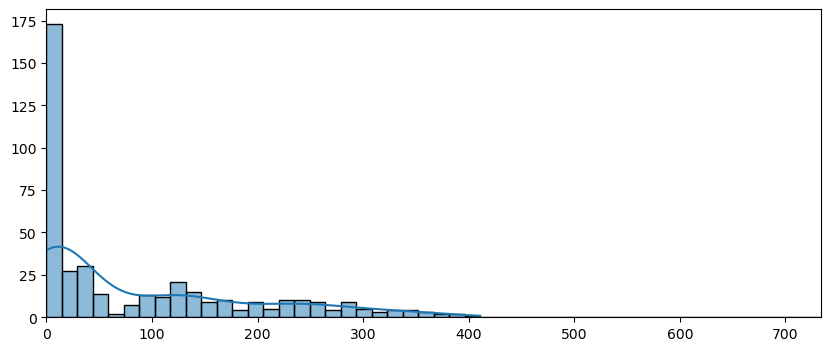

In [33]:
def display_abundhist(ax, metag, species, *, ksize=21, n_bins=50, title=None, verbose=False, label_axes=True, ymax=None):
    if ax is None:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))

    isect_sigfile = f"../outputs.abundhist/{species}.x.{metag}.isect.sig.zip"
    isect_sig = list(sourmash.load_file_as_signatures(isect_sigfile, ksize=ksize))
    assert len(isect_sig) == 1
    isect_sig = isect_sig[0]
    abunds = isect_sig.minhash.hashes

    # track hashval abundanc distribution
    counts_d = collections.defaultdict(int)
    # track abundance distribution, too
    counter = collections.Counter()

    for hashval, abund in abunds.items():
        abund = abunds[hashval]
        counts_d[hashval] += abund
        counter[abund] += 1

    all_counts = list(counts_d.values())
    counts_dist = list(counter.items())
    sum_hist = sum(counter.values())
    max_range = max(counter.values())
    min_range = 0

    # find count that covers 95% of distribution.
    sofar = 0
    for k, v in sorted(counts_dist):
        sofar += v
        if sofar >= 0.99*sum_hist:
            max_range = 2*k
            if verbose:
                print(f'setting default max_range to {max_range} (2x 99% of counts)')
            break
    
    sns.histplot(all_counts, ax=ax,
                     binrange=(min_range, max_range),
                     bins=n_bins, kde=True)

    #counts, bin_edges = np.histogram(all_counts,
    #                                 range=(min_range, max_range),
    #                                 bins=n_bins)
    #counts_bin3 = counts[2]

    if ymax:
        ax.set_ylim(top=ymax)
    #else:
    #    ax.set_ylim(top=counts_bin3)

    ax.set_xlim(min_range, max_range)

    if label_axes:
        ax.set_xlabel("k-mer abundance")
        ax.set_ylabel("N(k-mers at that abundance)")
    else:
        ax.set_ylabel("")

display_abundhist(None, 'SRR17241485', 's__Lactobacillus amylovorus', label_axes=False)

In [34]:
def plot_covhist_panel(species, metag_list, *, ymax=50, n_bins=50):
    fig, axes= plt.subplots(nrows=1, ncols=len(METAGS), figsize=(12, 4))
    fig.suptitle(species)
    
    for ax, metag in zip(axes, metag_list):
        depth_est, depth_all = get_cov_info(combo2_df, metag, species)
        #print(f'for {species} in {metag}, kmer depth: {depth_est:.1f} / mapping depth: {depth_all:.1f}')
        display_abundhist(ax, metag, species, label_axes=False, n_bins=n_bins, ymax=ymax)
        ax.set_title(metag)
    
        _, ymax = ax.get_ylim()
        ax.axvline(x=depth_est, color='red', linestyle='--', label='k-mer cov est')
        ax.axvline(x=depth_all, color='green', linestyle='--', label='gene mapping est')
        ax.set_xlabel('k-mer abundance')

    axes[0].legend(loc='upper right')
    axes[0].set_ylabel('num k-mers at that abundance')

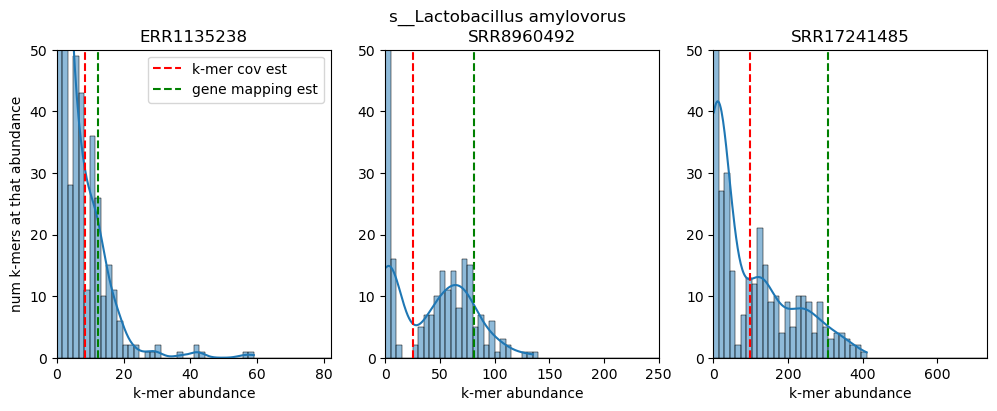

In [35]:
SS='s__Lactobacillus amylovorus'
METAGS=['ERR1135238', 'SRR8960492', 'SRR17241485']
plot_covhist_panel(SS, METAGS)

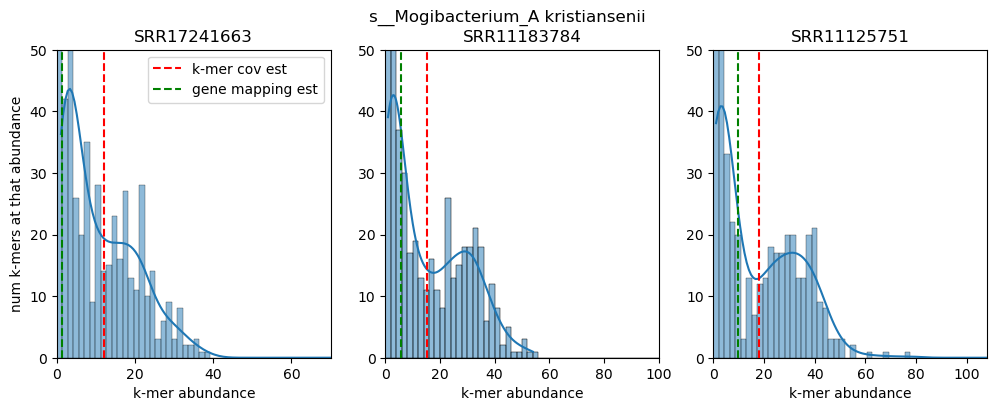

In [36]:
SS='s__Mogibacterium_A kristiansenii'

METAGS=[#'SRR14812372',
# 'SRR5240744',
 'SRR17241663',
# 'SRR8960625',
# 'SRR12795793',
 'SRR11183784',
# 'SRR17241609',
# 'SRR8960444',
 'SRR11125751',
# 'SRR8960379'
       ]

plot_covhist_panel(SS, METAGS)

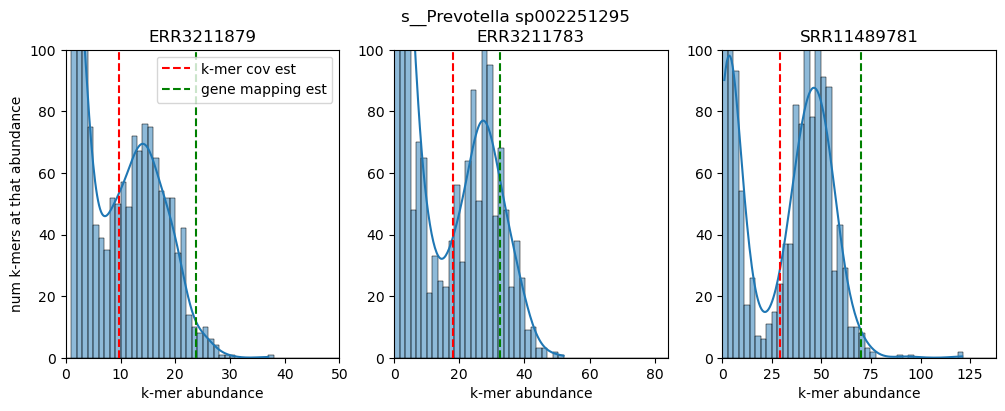

In [37]:
SS='s__Prevotella sp002251295'

METAGS=[
 #'SRR8960491',
 #'SRR5241534',
 #'ERR1135213',
 #'ERR3211839',
 'ERR3211879',
 #'ERR3211876',
 #'SRR14369134',
 'ERR3211783',
 #'SRR14369306',
 'SRR11489781']

plot_covhist_panel(SS, METAGS, ymax=100)

In [38]:
combo2_df['species'].unique()

species
str
"""s__Colivicinus sp002299675"""
"""s__Cryptobacteroides sp9005469…"
"""s__Lactobacillus amylovorus"""
"""s__Prevotella sp002251295"""
"""s__Sodaliphilus sp004557565"""
…
"""s__Ornithospirochaeta sp022785…"
"""s__Cryptobacteroides sp0340892…"
"""s__Cryptobacteroides sp0004349…"


In [39]:
SS='s__Prevotella sp000434975'

METAGS = [
#    'SRR8960379',
#   'SRR8960101',
#   'SRR14812375',
   'ERR3211876',
#   'SRR14812372',
#   'ERR1135303',
   'SRR11489769',
#   'ERR3211839',
   'ERR8314767',
#   'ERR1135349'
]

#plot_covhist_panel(SS, METAGS, ymax=100)

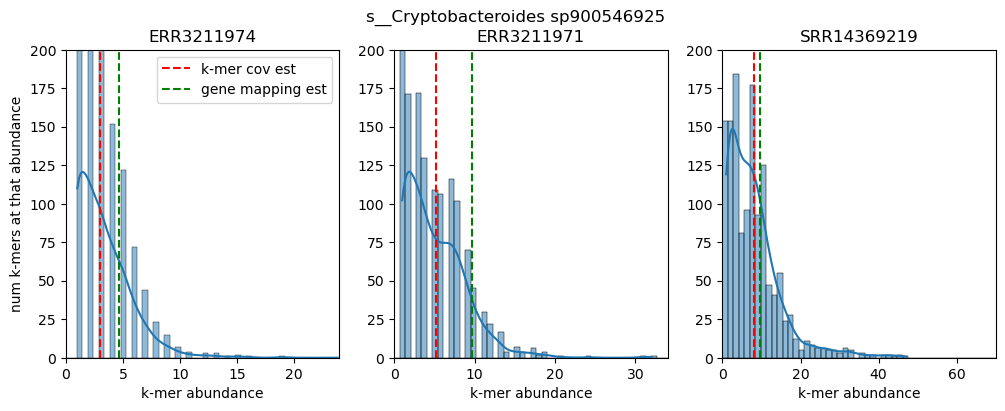

In [40]:
SS='s__Cryptobacteroides sp900546925'

METAGS = [#'SRR17241596',
                                          #'ERR3211812',
                                          'ERR3211974',
                                          #'ERR8314767',
                                          #'ERR8314788',
                                          'ERR3211971',
                                          #'SRR10209683',
                                          #'SRR11551383',
                                          'SRR14369219',
                                          #'SRR17241485'
         ]

plot_covhist_panel(SS, METAGS, ymax=200)

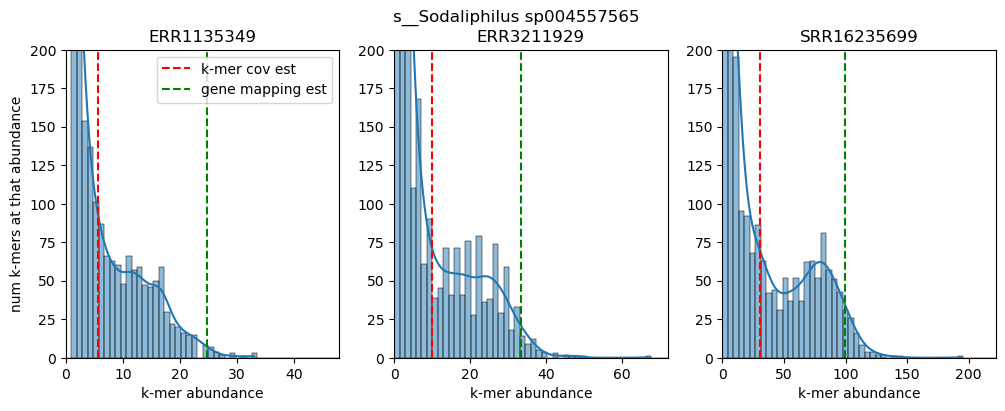

In [41]:
SS='s__Sodaliphilus sp004557565'

METAGS = [#'SRR11125534',
                                     #'SRR11805642',
                                     #'ERR8314743',
                                     'ERR1135349',
                                     #'ERR3211891',
                                     #'ERR8314788',
                                     'ERR3211929',
                                     #'ERR1135303',
                                     #'SRR10209683',
                                     'SRR16235699']

plot_covhist_panel(SS, METAGS, ymax=200)

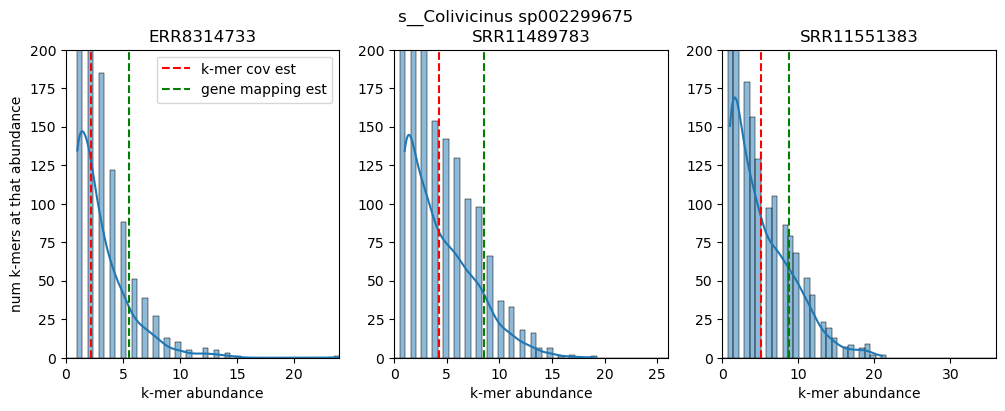

In [42]:
SS='s__Colivicinus sp002299675'

METAGS = [#'SRR5241534',
          #                         'ERR3211906',
          #                         'SRR5240744',
          #                         'ERR1135346',
          #                         'SRR17241663',
          #                         'SRR10209667',
          #                         'SRR12795793',
                                   'ERR8314733',
                                   'SRR11489783',
                                   'SRR11551383']

plot_covhist_panel(SS, METAGS, ymax=200)

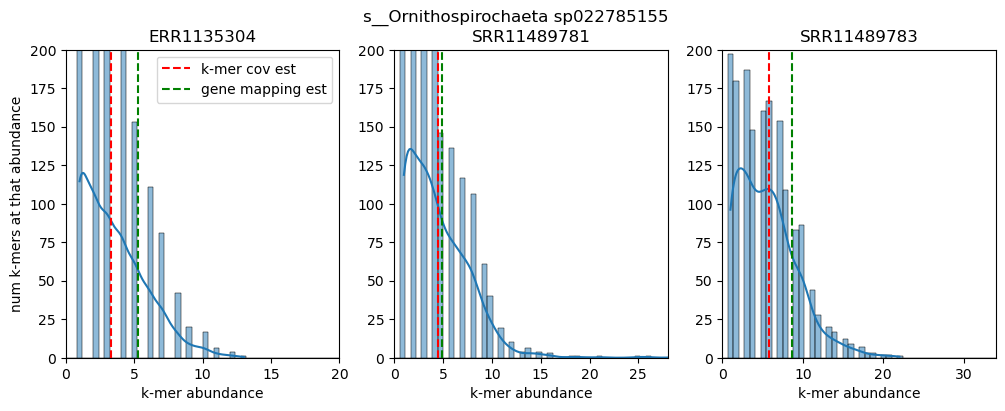

In [43]:
SS='s__Ornithospirochaeta sp022785155'

METAGS = [#'ERR1135273',
          #                                'ERR3211801',
          #                                'SRR18048904',
          #                                'ERR8314788',
          #                                'SRR8960625',
          #                                'ERR1135213',
          #                                'ERR3211929',
                                          'ERR1135304',
                                          'SRR11489781',
                                          'SRR11489783']

plot_covhist_panel(SS, METAGS, ymax=200)

TODO -
- look at gene-gene correlations systematically; plot, summarize?
- do more species
- pick specific anchor genes, and maybe remove others? or, indicate anchors in CSV.